# 1. Data Loading and Cleaning

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/posts.csv')
df.head()

,id,created_utc,subreddit,author,title,selftext,permalink,url
0,7nca41,1514768665,wallstreetbets,alreadyinuse5000,Blowing versus sucking,AAPL just entered a contract to purchase 51 of...,/r/wallstreetbets/comments/7nca41/blowing_vers...,https://www.reddit.com/r/wallstreetbets/commen...
1,7ncxcn,1514776674,pcmasterrace,castatech,Why is it that the new Windows 10 picture view...,What kind of an upgrade was this? It just suck...,/r/pcmasterrace/comments/7ncxcn/why_is_it_that...,https://www.reddit.com/r/pcmasterrace/comments...
2,7ndtyy,1514789593,TIMESINDIAauto,AutoNewsAdmin,[Business] - New year looks grim for McD’s staff,NaN,/r/TIMESINDIAauto/comments/7ndtyy/business_new...,https://timesofindia.indiatimes.com/business/i...
3,7ndu9l,1514789727,AutoNewspaper,AutoNewspaperAdmin,[Business] - New year looks grim for McD’s sta...,NaN,/r/AutoNewspaper/comments/7ndu9l/business_new_...,https://timesofindia.indiatimes.com/business/i...
4,7neolz,1514805270,teslamotors,AutoModerator,Bi-weekly TSLA Investor Thread,This will post every other Monday (EST) at 6AM...,/r/teslamotors/comments/7neolz/biweekly_tsla_i...,https://www.reddit.com/r/teslamotors/comments/...


**Define Text Cleaning Function**

In [ ]:
import re
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+|#\w+", "", text)
    text = re.sub(r"[^A-Za-z0-9\s]", "", text)
    text = text.lower().strip()
    return text


In [ ]:
df['title_clean'] = df['title'].apply(clean_text)
df['text_clean'] = df['selftext'].apply(clean_text)
df['date'] = pd.to_datetime(df['created_utc']).dt.date
df['full_text'] = df['title_clean'] + " " + df['text_clean']

In [ ]:
df['created_utc'] = pd.to_datetime(df['created_utc'], unit='s')
df['date'] = df['created_utc'].dt.date

# 2. Exploratory Data Analysis (EDA)

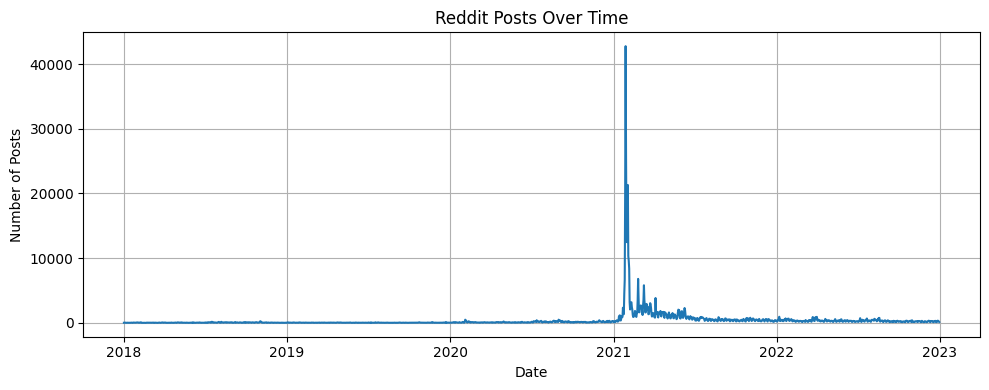

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
df.groupby('date').size().plot(kind='line', figsize=(10, 4), title='Reddit Posts Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.grid(True)
plt.tight_layout()
plt.show()

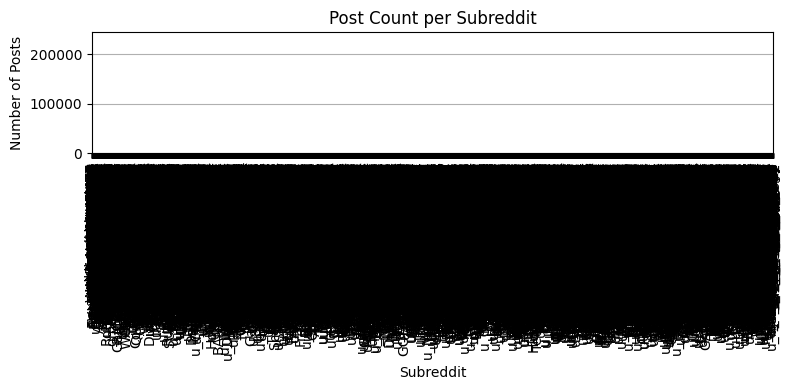

In [ ]:
df['subreddit'].value_counts().plot(kind='bar', figsize=(8, 4), title='Post Count per Subreddit')
plt.xlabel('Subreddit')
plt.ylabel('Number of Posts')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

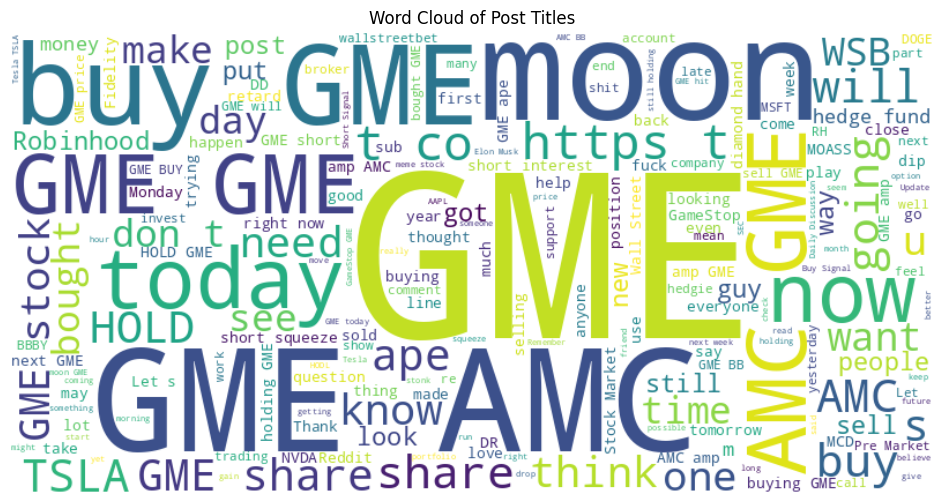

In [ ]:
from wordcloud import WordCloud

text = ' '.join(df['title'].dropna().astype(str).tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Post Titles')
plt.show()

# 3. Sentiment Classification and Modeling

In [ ]:
!pip install sentence-transformers transformers tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 46.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import re

# Load Sentiment140 dataset
cols = ['target', 'id', 'date', 'flag', 'user', 'text']
df140 = pd.read_csv('/content/drive/MyDrive/training.1600000.processed.noemoticon.csv', encoding='latin-1', names=cols)

# Keep only positive (4) and negative (0)
df140 = df140[df140['target'].isin([0, 4])].copy()
df140['label'] = df140['target'].replace({0: 0, 4: 1})

In [ ]:
def clean_text(text):
    return re.sub(r"http\\S+|www\\S+|[^A-Za-z0-9 ]+", " ", str(text)).lower().strip()

df140['text_clean'] = df140['text'].apply(clean_text)

In [ ]:
df140_rf = df140.copy()

**TF-IDF Vectorization**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
df140_rf = df140_rf[df140_rf['target'].isin([0, 4])]
df140_rf['target'] = df140_rf['target'].map({0: 0, 4: 1})

# 4. TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X = vectorizer.fit_transform(df140_rf['text'])
y = df140_rf['target']

**Train/Test Split and Evaluate Logistic Regression**

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.75      0.77    240000
           1       0.76      0.80      0.78    240000

    accuracy                           0.77    480000
   macro avg       0.77      0.77      0.77    480000
weighted avg       0.77      0.77      0.77    480000



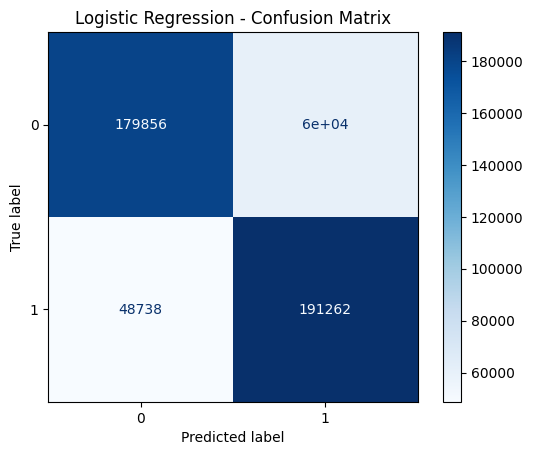

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 6. Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 7. Predict and evaluate
y_pred = model.predict(X_test)
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

# 8. Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


**Hyperparameter Tuning with GridSearchCV**

Fitting 3 folds for each of 8 candidates, totalling 24 fits
✅ Best Parameters: {'C': 1, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'}
🏆 Best F1 Score (CV): 0.7773743259651379
📊 Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.75      0.77    240000
           1       0.76      0.80      0.78    240000

    accuracy                           0.77    480000
   macro avg       0.77      0.77      0.77    480000
weighted avg       0.77      0.77      0.77    480000



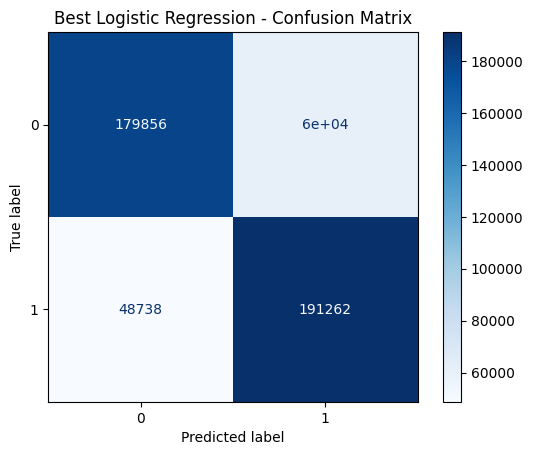

In [ ]:
from sklearn.model_selection import GridSearchCV
# Define the parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],                 # Regularization strength
    'penalty': ['l2'],                       # 'l1' requires solver='liblinear'
    'solver': ['lbfgs'],                     # fast and supports L2
    'max_iter': [500, 1000]                  # ensure convergence
}

# Setup GridSearch
grid = GridSearchCV(LogisticRegression(), param_grid, cv=3, scoring='f1', verbose=1, n_jobs=-1)

# Fit on training data
grid.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid.best_params_)
print("Best F1 Score (CV):", grid.best_score_)

# Evaluate best model on test set
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Test Set Classification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues')
plt.title("Best Logistic Regression - Confusion Matrix")
plt.show()

**Train and Evaluate XGBoost Classifier**

In [ ]:
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model_xgb.fit(X_train, y_train)

# Evaluate
y_pred = model_xgb.predict(X_test)
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:38:07] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       0.79      0.63      0.70    240000
           1       0.69      0.83      0.76    240000

    accuracy                           0.73    480000
   macro avg       0.74      0.73      0.73    480000
weighted avg       0.74      0.73      0.73    480000



# 4. Predict Sentiment Labels and Save Results

In [ ]:
df_features = vectorizer.transform(df['full_text'])

In [ ]:
df['predicted_label_LG'] = best_model.predict(df_features)

In [ ]:
df['predicted_label_XGB'] = model_xgb.predict(df_features)

** Preview and Save Labeled Dataset**

In [ ]:
df.head()

,id,created_utc,subreddit,author,title,selftext,permalink,url,title_clean,text_clean,date,full_text,predicted_label_LG,predicted_label_XGB
0,7nca41,2018-01-01 01:04:25,wallstreetbets,alreadyinuse5000,Blowing versus sucking,AAPL just entered a contract to purchase 51 of...,/r/wallstreetbets/comments/7nca41/blowing_vers...,https://www.reddit.com/r/wallstreetbets/commen...,blowing versus sucking,aapl just entered a contract to purchase 51 of...,2018-01-01,blowing versus sucking aapl just entered a con...,0,1
1,7ncxcn,2018-01-01 03:17:54,pcmasterrace,castatech,Why is it that the new Windows 10 picture view...,What kind of an upgrade was this? It just suck...,/r/pcmasterrace/comments/7ncxcn/why_is_it_that...,https://www.reddit.com/r/pcmasterrace/comments...,why is it that the new windows 10 picture view...,what kind of an upgrade was this it just sucks...,2018-01-01,why is it that the new windows 10 picture view...,0,0
2,7ndtyy,2018-01-01 06:53:13,TIMESINDIAauto,AutoNewsAdmin,[Business] - New year looks grim for McD’s staff,NaN,/r/TIMESINDIAauto/comments/7ndtyy/business_new...,https://timesofindia.indiatimes.com/business/i...,business new year looks grim for mcds staff,,2018-01-01,business new year looks grim for mcds staff,0,1
3,7ndu9l,2018-01-01 06:55:27,AutoNewspaper,AutoNewspaperAdmin,[Business] - New year looks grim for McD’s sta...,NaN,/r/AutoNewspaper/comments/7ndu9l/business_new_...,https://timesofindia.indiatimes.com/business/i...,business new year looks grim for mcds staff ...,,2018-01-01,business new year looks grim for mcds staff ...,0,1
4,7neolz,2018-01-01 11:14:30,teslamotors,AutoModerator,Bi-weekly TSLA Investor Thread,This will post every other Monday (EST) at 6AM...,/r/teslamotors/comments/7neolz/biweekly_tsla_i...,https://www.reddit.com/r/teslamotors/comments/...,biweekly tsla investor thread,this will post every other monday est at 6am ...,2018-01-01,biweekly tsla investor thread this will post e...,1,1


In [ ]:
df.to_csv("reddit_sentiment_labeled.csv", index=False)

# 5. Use Pretrained Transformer for Sentiment Classification

**Load Twitter-RoBERTa Sentiment Model**

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

classifier = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Device set to use cuda:0
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


**Load Labeled Dataset and Classify with RoBERTa**

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/reddit_sentiment_labeled (1).csv')
df.head()

,id,created_utc,subreddit,author,title,selftext,permalink,url,title_clean,text_clean,date,full_text,predicted_label_LG,predicted_label_XGB
0,7nca41,2018-01-01 01:04:25,wallstreetbets,alreadyinuse5000,Blowing versus sucking,AAPL just entered a contract to purchase 51 of...,/r/wallstreetbets/comments/7nca41/blowing_vers...,https://www.reddit.com/r/wallstreetbets/commen...,blowing versus sucking,aapl just entered a contract to purchase 51 of...,2018-01-01,blowing versus sucking aapl just entered a con...,0,1
1,7ncxcn,2018-01-01 03:17:54,pcmasterrace,castatech,Why is it that the new Windows 10 picture view...,What kind of an upgrade was this? It just suck...,/r/pcmasterrace/comments/7ncxcn/why_is_it_that...,https://www.reddit.com/r/pcmasterrace/comments...,why is it that the new windows 10 picture view...,what kind of an upgrade was this it just sucks...,2018-01-01,why is it that the new windows 10 picture view...,0,0
2,7ndtyy,2018-01-01 06:53:13,TIMESINDIAauto,AutoNewsAdmin,[Business] - New year looks grim for McD’s staff,NaN,/r/TIMESINDIAauto/comments/7ndtyy/business_new...,https://timesofindia.indiatimes.com/business/i...,business new year looks grim for mcds staff,NaN,2018-01-01,business new year looks grim for mcds staff,0,1
3,7ndu9l,2018-01-01 06:55:27,AutoNewspaper,AutoNewspaperAdmin,[Business] - New year looks grim for McD’s sta...,NaN,/r/AutoNewspaper/comments/7ndu9l/business_new_...,https://timesofindia.indiatimes.com/business/i...,business new year looks grim for mcds staff ...,NaN,2018-01-01,business new year looks grim for mcds staff ...,0,1
4,7neolz,2018-01-01 11:14:30,teslamotors,AutoModerator,Bi-weekly TSLA Investor Thread,This will post every other Monday (EST) at 6AM...,/r/teslamotors/comments/7neolz/biweekly_tsla_i...,https://www.reddit.com/r/teslamotors/comments/...,biweekly tsla investor thread,this will post every other monday est at 6am ...,2018-01-01,biweekly tsla investor thread this will post e...,1,1


**Apply RoBERTa Model to Classify Sentimen**

In [ ]:
from tqdm import tqdm
tqdm.pandas()

label_map = {
    'LABEL_0': 'negative',
    'LABEL_1': 'neutral',
    'LABEL_2': 'positive'
}

def classify_sentiment(text):
    try:
        result = classifier(text)[0]
        return label_map.get(result['label'], 'unknown')
    except Exception:
        return 'error'

In [ ]:
df['sentiment'] = df['full_text'].progress_apply(classify_sentiment)

100%|██████████| 727182/727182 [11:12<00:00, 1082.11it/s]


In [ ]:
df.head()

,id,created_utc,subreddit,author,title,selftext,permalink,url,title_clean,text_clean,date,full_text,predicted_label_LG,predicted_label_XGB,sentiment
0,7nca41,2018-01-01 01:04:25,wallstreetbets,alreadyinuse5000,Blowing versus sucking,AAPL just entered a contract to purchase 51 of...,/r/wallstreetbets/comments/7nca41/blowing_vers...,https://www.reddit.com/r/wallstreetbets/commen...,blowing versus sucking,aapl just entered a contract to purchase 51 of...,2018-01-01,blowing versus sucking aapl just entered a con...,0,1,negative
1,7ncxcn,2018-01-01 03:17:54,pcmasterrace,castatech,Why is it that the new Windows 10 picture view...,What kind of an upgrade was this? It just suck...,/r/pcmasterrace/comments/7ncxcn/why_is_it_that...,https://www.reddit.com/r/pcmasterrace/comments...,why is it that the new windows 10 picture view...,what kind of an upgrade was this it just sucks...,2018-01-01,why is it that the new windows 10 picture view...,0,0,negative
2,7ndtyy,2018-01-01 06:53:13,TIMESINDIAauto,AutoNewsAdmin,[Business] - New year looks grim for McD’s staff,NaN,/r/TIMESINDIAauto/comments/7ndtyy/business_new...,https://timesofindia.indiatimes.com/business/i...,business new year looks grim for mcds staff,NaN,2018-01-01,business new year looks grim for mcds staff,0,1,negative
3,7ndu9l,2018-01-01 06:55:27,AutoNewspaper,AutoNewspaperAdmin,[Business] - New year looks grim for McD’s sta...,NaN,/r/AutoNewspaper/comments/7ndu9l/business_new_...,https://timesofindia.indiatimes.com/business/i...,business new year looks grim for mcds staff ...,NaN,2018-01-01,business new year looks grim for mcds staff ...,0,1,negative
4,7neolz,2018-01-01 11:14:30,teslamotors,AutoModerator,Bi-weekly TSLA Investor Thread,This will post every other Monday (EST) at 6AM...,/r/teslamotors/comments/7neolz/biweekly_tsla_i...,https://www.reddit.com/r/teslamotors/comments/...,biweekly tsla investor thread,this will post every other monday est at 6am ...,2018-01-01,biweekly tsla investor thread this will post e...,1,1,neutral


# 7. Filter and Encode Sentiment Labels

**Drop Unnecessary Columns**

In [ ]:
columns_to_drop = [
    'url', 'title', 'selftext', 'author', 'created_utc', 'id'
    ,'permalink'

]

# Drop them from the DataFrame
df_cleaned = df.drop(columns=columns_to_drop)

In [ ]:
df_cleaned.head()

,subreddit,title_clean,text_clean,date,full_text,predicted_label_LG,predicted_label_XGB,sentiment
0,wallstreetbets,blowing versus sucking,aapl just entered a contract to purchase 51 of...,2018-01-01,blowing versus sucking aapl just entered a con...,0,1,negative
1,pcmasterrace,why is it that the new windows 10 picture view...,what kind of an upgrade was this it just sucks...,2018-01-01,why is it that the new windows 10 picture view...,0,0,negative
2,TIMESINDIAauto,business new year looks grim for mcds staff,NaN,2018-01-01,business new year looks grim for mcds staff,0,1,negative
3,AutoNewspaper,business new year looks grim for mcds staff ...,NaN,2018-01-01,business new year looks grim for mcds staff ...,0,1,negative
4,teslamotors,biweekly tsla investor thread,this will post every other monday est at 6am ...,2018-01-01,biweekly tsla investor thread this will post e...,1,1,neutral


**Map Sentiment Labels to Numeric Format**

In [ ]:
sentiment_map = {
    'negative': 0,
    'neutral': -1,
    'positive': 1
}

# Apply mapping
df_cleaned['sentiment_encoded'] = df['sentiment'].map(sentiment_map)

In [ ]:
df_cleaned.head()

,subreddit,title_clean,text_clean,date,full_text,predicted_label_LG,predicted_label_XGB,sentiment,sentiment_encoded
0,wallstreetbets,blowing versus sucking,aapl just entered a contract to purchase 51 of...,2018-01-01,blowing versus sucking aapl just entered a con...,0,1,negative,0.0
1,pcmasterrace,why is it that the new windows 10 picture view...,what kind of an upgrade was this it just sucks...,2018-01-01,why is it that the new windows 10 picture view...,0,0,negative,0.0
2,TIMESINDIAauto,business new year looks grim for mcds staff,NaN,2018-01-01,business new year looks grim for mcds staff,0,1,negative,0.0
3,AutoNewspaper,business new year looks grim for mcds staff ...,NaN,2018-01-01,business new year looks grim for mcds staff ...,0,1,negative,0.0
4,teslamotors,biweekly tsla investor thread,this will post every other monday est at 6am ...,2018-01-01,biweekly tsla investor thread this will post e...,1,1,neutral,-1.0


**Filter Rows with Model Agreement or Neutral Cases**

In [ ]:
filtered_df = df_cleaned[
    (df_cleaned['predicted_label_LG'] == df_cleaned['sentiment_encoded']) |
    (df_cleaned['sentiment_encoded'] == -1) |  # Neutral sentiment
    (df_cleaned['predicted_label_XGB'] == df_cleaned['sentiment_encoded']) |
     (df_cleaned['predicted_label_XGB'] == df_cleaned['predicted_label_LG'])

]

In [ ]:
filtered_df.head()

,subreddit,title_clean,text_clean,date,full_text,predicted_label_LG,predicted_label_XGB,sentiment,sentiment_encoded
0,wallstreetbets,blowing versus sucking,aapl just entered a contract to purchase 51 of...,2018-01-01,blowing versus sucking aapl just entered a con...,0,1,negative,0.0
1,pcmasterrace,why is it that the new windows 10 picture view...,what kind of an upgrade was this it just sucks...,2018-01-01,why is it that the new windows 10 picture view...,0,0,negative,0.0
2,TIMESINDIAauto,business new year looks grim for mcds staff,NaN,2018-01-01,business new year looks grim for mcds staff,0,1,negative,0.0
3,AutoNewspaper,business new year looks grim for mcds staff ...,NaN,2018-01-01,business new year looks grim for mcds staff ...,0,1,negative,0.0
4,teslamotors,biweekly tsla investor thread,this will post every other monday est at 6am ...,2018-01-01,biweekly tsla investor thread this will post e...,1,1,neutral,-1.0


**Save Filtered Data for Final Merging**

In [ ]:
filtered_df.to_csv("filtered_reddit_data.csv", index=False)

In [ ]:
df_cleaned.shape

(727182, 9)

In [ ]:
filtered_df.shape

(398660, 9)

# 9. Combine Predictions with Majority Voting

In [ ]:
def majority_label(row):
    votes = [
        row['sentiment_encoded'],
        row['predicted_label_LG'],
        row['predicted_label_XGB']
    ]

    if -1 in votes:
        return -1

    # Count positives and negatives
    positive_votes = votes.count(1)
    negative_votes = votes.count(0)

    if positive_votes >= 2:
        return 1
    elif negative_votes >= 2:
        return 0
    else:
        return "conflict"  # Edge case: 1 pos, 1 neg, 1 missing


In [ ]:
filtered_df['final_label'] = filtered_df.apply(majority_label, axis=1)

<ipython-input-33-c17c49359333>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['final_label'] = filtered_df.apply(majority_label, axis=1)


In [ ]:
filtered_df['final_label'].value_counts()

,count
final_label,
1,223676
0,174235
-1,749


In [ ]:
filtered_df.to_csv("filtered_reddit_data.csv", index=False)

In [ ]:
filtered_df.head()

,subreddit,title_clean,text_clean,date,full_text,predicted_label_LG,predicted_label_XGB,sentiment,sentiment_encoded,final_label
0,wallstreetbets,blowing versus sucking,aapl just entered a contract to purchase 51 of...,2018-01-01,blowing versus sucking aapl just entered a con...,0,1,negative,0.0,0
1,pcmasterrace,why is it that the new windows 10 picture view...,what kind of an upgrade was this it just sucks...,2018-01-01,why is it that the new windows 10 picture view...,0,0,negative,0.0,0
2,TIMESINDIAauto,business new year looks grim for mcds staff,NaN,2018-01-01,business new year looks grim for mcds staff,0,1,negative,0.0,0
3,AutoNewspaper,business new year looks grim for mcds staff ...,NaN,2018-01-01,business new year looks grim for mcds staff ...,0,1,negative,0.0,0
4,teslamotors,biweekly tsla investor thread,this will post every other monday est at 6am ...,2018-01-01,biweekly tsla investor thread this will post e...,1,1,neutral,-1.0,-1


# 10. Extract Tickers Mentioned in Posts

In [ ]:
import re
tickers = ['AAPL', 'GME', 'MCD', 'MSFT', 'NFLX', 'NVDA', 'TSLA']
def extract_tickers(text):
    if not isinstance(text, str):
        return None
    matches = re.findall(r'\b[A-Z]{2,5}\b', text.upper())
    found = list(set(matches).intersection(tickers))
    return ','.join(found) if found else None

filtered_df['label'] = filtered_df['full_text'].apply(extract_tickers)

<ipython-input-39-fa07890a04a2>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['label'] = filtered_df['full_text'].apply(extract_tickers)


In [ ]:
filtered_df.head()

,subreddit,title_clean,text_clean,date,full_text,predicted_label_LG,predicted_label_XGB,sentiment,sentiment_encoded,final_label,label
0,wallstreetbets,blowing versus sucking,aapl just entered a contract to purchase 51 of...,2018-01-01,blowing versus sucking aapl just entered a con...,0,1,negative,0.0,0,AAPL
1,pcmasterrace,why is it that the new windows 10 picture view...,what kind of an upgrade was this it just sucks...,2018-01-01,why is it that the new windows 10 picture view...,0,0,negative,0.0,0,MSFT
2,TIMESINDIAauto,business new year looks grim for mcds staff,NaN,2018-01-01,business new year looks grim for mcds staff,0,1,negative,0.0,0,None
3,AutoNewspaper,business new year looks grim for mcds staff ...,NaN,2018-01-01,business new year looks grim for mcds staff ...,0,1,negative,0.0,0,None
4,teslamotors,biweekly tsla investor thread,this will post every other monday est at 6am ...,2018-01-01,biweekly tsla investor thread this will post e...,1,1,neutral,-1.0,-1,TSLA


In [ ]:
filtered_df['label'].isna().sum()

np.int64(30246)

In [ ]:
filtered_df['label'] = filtered_df['label'].fillna('unknown')

<ipython-input-42-3201f2762504>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['label'] = filtered_df['label'].fillna('unknown')


In [ ]:
filtered_df.head()

,subreddit,title_clean,text_clean,date,full_text,predicted_label_LG,predicted_label_XGB,sentiment,sentiment_encoded,final_label,label
0,wallstreetbets,blowing versus sucking,aapl just entered a contract to purchase 51 of...,2018-01-01,blowing versus sucking aapl just entered a con...,0,1,negative,0.0,0,AAPL
1,pcmasterrace,why is it that the new windows 10 picture view...,what kind of an upgrade was this it just sucks...,2018-01-01,why is it that the new windows 10 picture view...,0,0,negative,0.0,0,MSFT
2,TIMESINDIAauto,business new year looks grim for mcds staff,NaN,2018-01-01,business new year looks grim for mcds staff,0,1,negative,0.0,0,unknown
3,AutoNewspaper,business new year looks grim for mcds staff ...,NaN,2018-01-01,business new year looks grim for mcds staff ...,0,1,negative,0.0,0,unknown
4,teslamotors,biweekly tsla investor thread,this will post every other monday est at 6am ...,2018-01-01,biweekly tsla investor thread this will post e...,1,1,neutral,-1.0,-1,TSLA


In [ ]:
filtered_df.to_csv("labeled_filtered_reddit_data.csv", index=False)

In [ ]:
import pandas as pd

filtered_df = pd.read_csv('/content/labeled_filtered_reddit_data.csv')

In [ ]:
filtered_df = filtered_df[filtered_df['label'] != 'unknown']

# 11. Fetch Stock Price Data

In [ ]:
!pip install pandas_datareader

In [ ]:
import pandas_datareader.data as web
import pandas as pd
from datetime import datetime

tickers = ['AAPL', 'TSLA', 'GME', 'NFLX', 'MSFT', 'MCD', 'NVDA']
start_date = datetime(2018, 1, 1)
end_date = datetime(2023, 1, 1)

all_data = []

for ticker in tickers:
    print(f"Fetching: {ticker}")
    try:
        df = web.DataReader(ticker, 'stooq', start_date, end_date)
        df['ticker'] = ticker
        df = df.reset_index()
        all_data.append(df)
    except Exception as e:
        print(f"Failed for {ticker}: {e}")


Fetching: AAPL
Fetching: TSLA
Fetching: GME
Fetching: NFLX
Fetching: MSFT
Fetching: MCD
Fetching: NVDA


In [ ]:
all_data

[           Date      Open      High       Low     Close     Volume ticker
 0    2022-12-30  126.9330  128.4570  125.9670  128.4370   77929881   AAPL
 1    2022-12-29  126.5190  128.9810  126.2620  128.1200   76583912   AAPL
 2    2022-12-28  128.1800  129.5220  124.4230  124.5910   86431778   AAPL
 3    2022-12-27  129.8690  129.8990  127.2400  128.5360   69810179   AAPL
 4    2022-12-23  129.4140  130.8930  128.1500  130.3450   64556865   AAPL
 ...         ...       ...       ...       ...       ...        ...    ...
 1254 2018-01-08   40.9712   41.2677   40.8748   40.9811   87365935   AAPL
 1255 2018-01-05   40.7582   41.2136   40.6699   41.1220  100413538   AAPL
 1256 2018-01-04   40.5454   40.7661   40.4361   40.6639   95104622   AAPL
 1257 2018-01-03   40.5435   41.0145   40.4064   40.4725  125393932   AAPL
 1258 2018-01-02   39.9866   40.4883   39.7750   40.4794  108596378   AAPL
 
 [1259 rows x 7 columns],
            Date      Open      High       Low     Close     Volume tick

In [ ]:
price_data = pd.concat(all_data, ignore_index=True)
price_data['Date'] = pd.to_datetime(price_data['Date']).dt.date

In [ ]:
price_data = price_data.sort_values(by=['ticker', 'Date']).reset_index(drop=True)

In [ ]:
filtered_df['date'] = pd.to_datetime(filtered_df['date']).dt.date

# Handle multiple tickers (if any still exist, though you removed 'unknown')
filtered_df['label_list'] = filtered_df['label'].apply(lambda x: x.split(',') if ',' in x else [x])
filtered_df = filtered_df.explode('label_list')


In [ ]:
price_data.head()

,Date,Open,High,Low,Close,Volume,ticker
0,2018-01-02,39.9866,40.4883,39.7750,40.4794,108596378.0,AAPL
1,2018-01-03,40.5435,41.0145,40.4064,40.4725,125393932.0,AAPL
2,2018-01-04,40.5454,40.7661,40.4361,40.6639,95104622.0,AAPL
3,2018-01-05,40.7582,41.2136,40.6699,41.1220,100413538.0,AAPL
4,2018-01-08,40.9712,41.2677,40.8748,40.9811,87365935.0,AAPL


In [ ]:
price_data = price_data.sort_values(by=['ticker', 'Date'])
price_data['daily_return'] = price_data.groupby('ticker')['Close'].pct_change()


In [ ]:
price_data

,Date,Open,High,Low,Close,Volume,ticker,daily_return
0,2018-01-02,39.9866,40.4883,39.7750,40.4794,108596378.0,AAPL,NaN
1,2018-01-03,40.5435,41.0145,40.4064,40.4725,125393932.0,AAPL,-0.000170
2,2018-01-04,40.5454,40.7661,40.4361,40.6639,95104622.0,AAPL,0.004729
3,2018-01-05,40.7582,41.2136,40.6699,41.1220,100413538.0,AAPL,0.011266
4,2018-01-08,40.9712,41.2677,40.8748,40.9811,87365935.0,AAPL,-0.003426
...,...,...,...,...,...,...,...,...
8808,2022-12-23,126.3700,128.6173,121.0200,123.1500,166989688.0,TSLA,-0.017551
8809,2022-12-27,117.4950,119.6700,108.7600,109.1000,208643444.0,TSLA,-0.114089
8810,2022-12-28,110.3500,116.2700,108.2400,112.7100,221070537.0,TSLA,0.033089
8811,2022-12-29,120.3850,123.5700,117.4950,121.8200,221923313.0,TSLA,0.080827


In [ ]:
price_data['ticker'] = price_data['ticker'].str.strip().str.upper()
filtered_df['label_list'] = filtered_df['label_list'].str.strip().str.upper()
price_data['Date'] = pd.to_datetime(price_data['Date']).dt.date
filtered_df['date'] = pd.to_datetime(filtered_df['date']).dt.date

In [ ]:
price_data

,Date,Open,High,Low,Close,Volume,ticker,daily_return
0,2018-01-02,39.9866,40.4883,39.7750,40.4794,108596378.0,AAPL,NaN
1,2018-01-03,40.5435,41.0145,40.4064,40.4725,125393932.0,AAPL,-0.000170
2,2018-01-04,40.5454,40.7661,40.4361,40.6639,95104622.0,AAPL,0.004729
3,2018-01-05,40.7582,41.2136,40.6699,41.1220,100413538.0,AAPL,0.011266
4,2018-01-08,40.9712,41.2677,40.8748,40.9811,87365935.0,AAPL,-0.003426
...,...,...,...,...,...,...,...,...
8808,2022-12-23,126.3700,128.6173,121.0200,123.1500,166989688.0,TSLA,-0.017551
8809,2022-12-27,117.4950,119.6700,108.7600,109.1000,208643444.0,TSLA,-0.114089
8810,2022-12-28,110.3500,116.2700,108.2400,112.7100,221070537.0,TSLA,0.033089
8811,2022-12-29,120.3850,123.5700,117.4950,121.8200,221923313.0,TSLA,0.080827


# 12. Merge Reddit Data with Stock Prices

In [ ]:
# Get valid market dates from price_data
valid_dates = price_data['Date'].unique()

# Convert both to date for consistency
filtered_df['date'] = pd.to_datetime(filtered_df['date']).dt.date
price_data['Date'] = pd.to_datetime(price_data['Date']).dt.date

# Filter posts to only include valid trading days
filtered_df = filtered_df[filtered_df['date'].isin(valid_dates)]


In [ ]:
price_df = price_data.rename(columns={'Date': 'date', 'ticker': 'label_list'})

# Merge
merged_df = pd.merge(
    filtered_df,
    price_df[['date', 'label_list', 'Close']],
    on=['date', 'label_list'],
    how='left'
)

In [ ]:
price_df

,date,Open,High,Low,Close,Volume,label_list,daily_return
0,2018-01-02,39.9866,40.4883,39.7750,40.4794,108596378.0,AAPL,NaN
1,2018-01-03,40.5435,41.0145,40.4064,40.4725,125393932.0,AAPL,-0.000170
2,2018-01-04,40.5454,40.7661,40.4361,40.6639,95104622.0,AAPL,0.004729
3,2018-01-05,40.7582,41.2136,40.6699,41.1220,100413538.0,AAPL,0.011266
4,2018-01-08,40.9712,41.2677,40.8748,40.9811,87365935.0,AAPL,-0.003426
...,...,...,...,...,...,...,...,...
8808,2022-12-23,126.3700,128.6173,121.0200,123.1500,166989688.0,TSLA,-0.017551
8809,2022-12-27,117.4950,119.6700,108.7600,109.1000,208643444.0,TSLA,-0.114089
8810,2022-12-28,110.3500,116.2700,108.2400,112.7100,221070537.0,TSLA,0.033089
8811,2022-12-29,120.3850,123.5700,117.4950,121.8200,221923313.0,TSLA,0.080827


# 14. Calculate Forward Returns and Label Directions

In [ ]:
merged_df = merged_df.sort_values(by=['label_list', 'date'])

In [ ]:
merged_df['daily_return'] = merged_df.groupby('label_list')['Close'].shift(-10) / merged_df['Close'] - 1



In [ ]:
merged_df['daily_return'].value_counts()

,count
daily_return,
0.000000,262606
0.004987,10
-0.014432,10
0.008493,10
-0.004378,10
...,...
0.028807,1
0.025704,1
0.033699,1


In [ ]:
merged_df.head()

,subreddit,title_clean,text_clean,date,full_text,predicted_label_LG,predicted_label_XGB,sentiment,sentiment_encoded,final_label,label,label_list,Close,daily_return
0,thewallstreet,citi 40 chance aapl buys nflx,NaN,2018-01-02,citi 40 chance aapl buys nflx,0,1,neutral,-1.0,-1,"AAPL,NFLX",AAPL,40.4794,-0.00017
4,StockMarket,thinking about investing and using margin but ...,so i have dabbled in stock trading off and on ...,2018-01-02,thinking about investing and using margin but ...,0,0,positive,1.0,0,"AAPL,MSFT",AAPL,40.4794,-0.00017
6,Conservative,there is a 40 chance apple will acquire netfli...,NaN,2018-01-02,there is a 40 chance apple will acquire netfli...,0,1,neutral,-1.0,-1,"AAPL,NFLX",AAPL,40.4794,-0.00017
8,StocksAndBoobs,there is a 40 chance apple will acquire netfli...,NaN,2018-01-02,there is a 40 chance apple will acquire netfli...,0,1,neutral,-1.0,-1,"AAPL,NFLX",AAPL,40.4794,-0.00017
12,newstweetfeed,livesquawk aapl apple users may be unable to s...,NaN,2018-01-02,livesquawk aapl apple users may be unable to s...,0,1,negative,0.0,0,AAPL,AAPL,40.4794,-0.00017


In [ ]:
def label_return_direction(r):
    if pd.isna(r):
        return 'no_data'
    elif r > 0.001:
        return 'up'
    elif r < -0.001:
        return 'down'
    else:
        return 'neutral'

merged_df['daily_return_direction'] = merged_df['daily_return'].apply(label_return_direction)


In [ ]:
merged_df.value_counts('daily_return_direction')

,count
daily_return_direction,
neutral,264316
up,26267
down,23611
no_data,70


**Visualize Return Distribution**

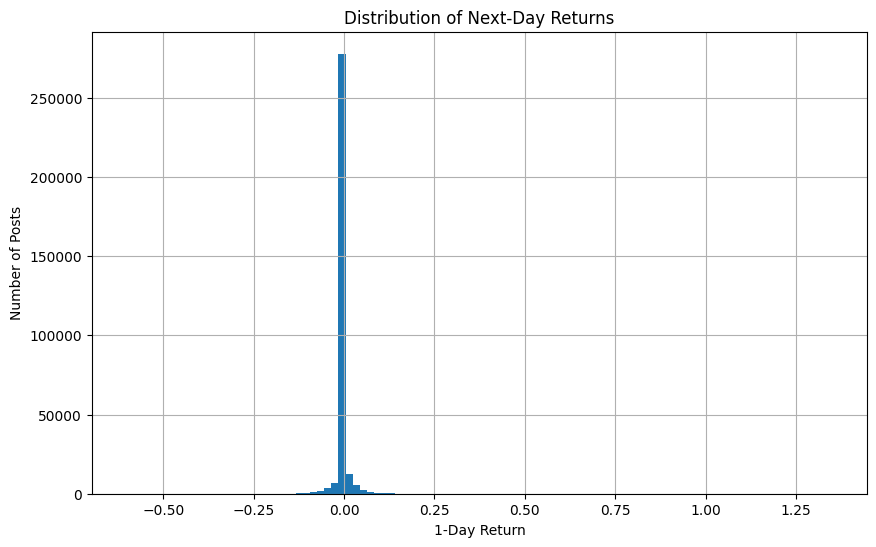

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
merged_df['daily_return'].hist(bins=100)
plt.title("Distribution of Next-Day Returns")
plt.xlabel("1-Day Return")
plt.ylabel("Number of Posts")
plt.grid(True)
plt.show()

In [ ]:
print(merged_df.columns.tolist())

['subreddit', 'title_clean', 'text_clean', 'date', 'full_text', 'predicted_label_LG', 'predicted_label_XGB', 'sentiment', 'sentiment_encoded', 'final_label', 'label', 'label_list', 'Close', 'daily_return', 'daily_return_direction']


In [ ]:
cleaned_df = merged_df.copy()
columns_to_drop = ['sentiment', 'label',]
cleaned_df = cleaned_df.drop(columns=columns_to_drop)

In [ ]:
cleaned_df.rename(columns={'label_list': 'ticker','final_label':'final_prediction'}, inplace=True)

# 15. Final Cleaning and Class Rebalancing

In [ ]:
cleaned_df.to_csv("cleaned_reddit_data.csv", index=False)

In [ ]:
import pandas as pd

cleaned_df = pd.read_csv('/content/cleaned_reddit_data.csv')

In [ ]:
final_df = cleaned_df.copy()

In [ ]:
final_df.value_counts("daily_return_direction")

,count
daily_return_direction,
neutral,264316
up,26267
down,23611
no_data,70


In [ ]:
neutral_gme = final_df[(final_df['daily_return_direction'] == 'neutral') & (final_df['ticker'] == 'GME')]
neutral_other = final_df[(final_df['daily_return_direction'] == 'neutral') & (final_df['ticker'] == 'TSLA')]

In [ ]:
neutral_other.shape

(21450, 13)

In [ ]:
gme_neutral = final_df[(final_df['daily_return_direction'] == 'neutral') & (final_df['ticker'] == 'GME')]
gme_neutral_sampled = gme_neutral.sample(n=26000, random_state=42)

# Step 2: Get all 'up' and 'down' rows (regardless of ticker)
up_down = final_df[final_df['daily_return_direction'].isin(['up', 'down'])]

# Step 3: Combine everything, preserving all columns
final_df = pd.concat([gme_neutral_sampled, up_down], ignore_index=True)

# Step 4: Confirm class distribution
print(final_df['daily_return_direction'].value_counts())
print(final_df.shape)

daily_return_direction
up         26267
neutral    26000
down       23611
Name: count, dtype: int64
(75878, 13)


# 16. Visualize Class Distribution After Balancing

In [ ]:
df = final_df.copy()

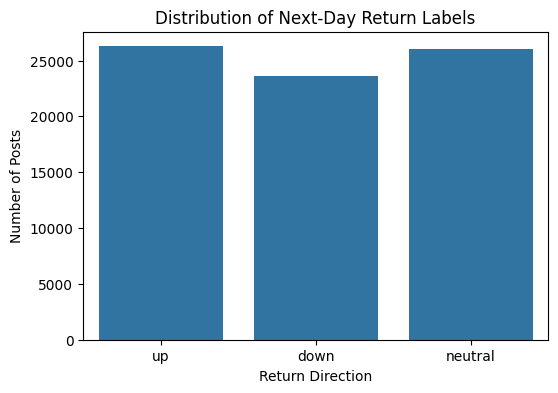

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='daily_return_direction', order=['up', 'down', 'neutral'])
plt.title("Distribution of Next-Day Return Labels")
plt.xlabel("Return Direction")
plt.ylabel("Number of Posts")
plt.show()


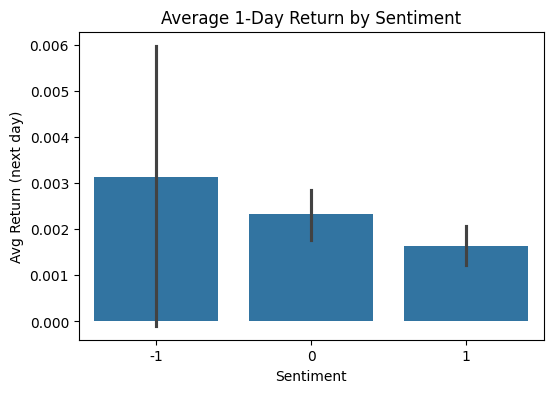

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='final_prediction', y='daily_return')
plt.title("Average 1-Day Return by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Avg Return (next day)")
plt.show()

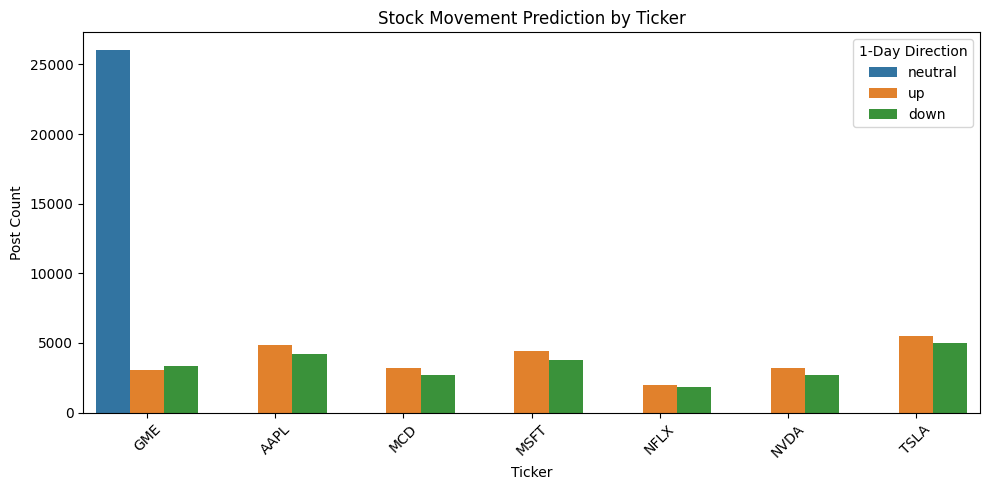

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='ticker', hue='daily_return_direction')
plt.title("Stock Movement Prediction by Ticker")
plt.xlabel("Ticker")
plt.ylabel("Post Count")
plt.legend(title='1-Day Direction')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


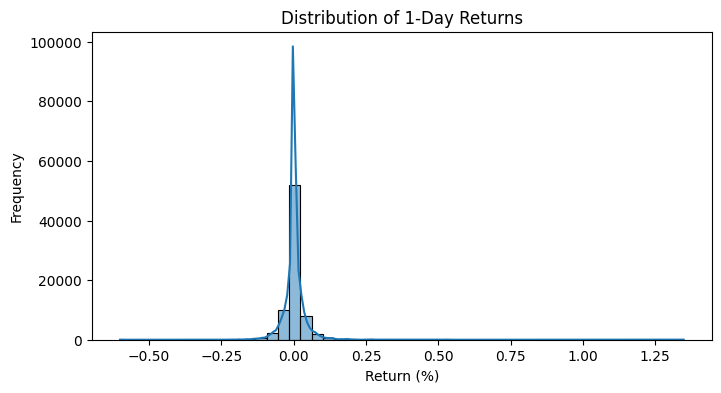

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df['daily_return'].dropna(), bins=50, kde=True)
plt.title("Distribution of 1-Day Returns")
plt.xlabel("Return (%)")
plt.ylabel("Frequency")
plt.show()


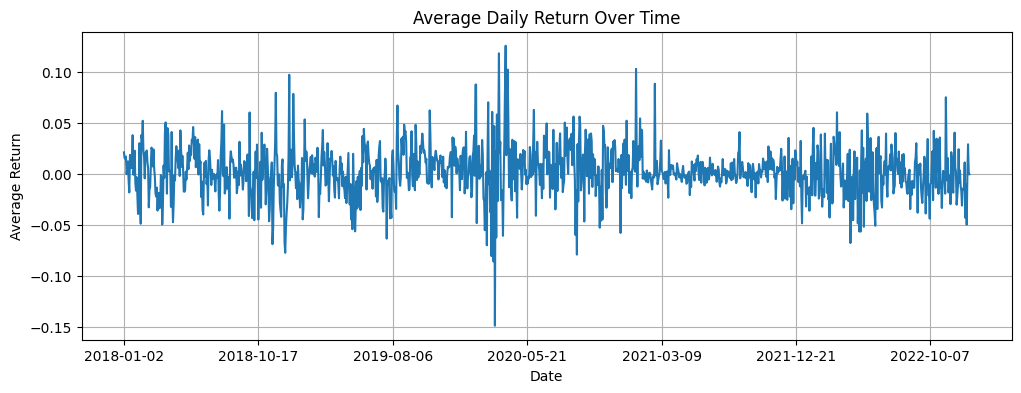

In [ ]:
daily_avg = df.groupby('date')['daily_return'].mean().dropna()

plt.figure(figsize=(12, 4))
daily_avg.plot()
plt.title("Average Daily Return Over Time")
plt.xlabel("Date")
plt.ylabel("Average Return")
plt.grid(True)
plt.show()


# 17. Model Preparation and Training (XGBoost)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Combine text + sentiment
final_df['input_text'] = (
    "Sentiment: " + final_df['final_prediction'].astype(str) + " "
    + final_df['title_clean'].fillna('') + " " + final_df['text_clean'].fillna('')
)

X_text = final_df['input_text']
y = final_df['daily_return_direction']  # 'up', 'down', 'neutral'

# TF-IDF
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X = vectorizer.fit_transform(X_text)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)


**Train & Evaluate Final XGBoost Model**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

model = XGBClassifier(eval_metric='mlogloss', use_label_encoder=False)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:37:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

        down       0.56      0.26      0.36      7107
     neutral       0.81      0.99      0.89      7714
          up       0.57      0.71      0.63      7943

    accuracy                           0.66     22764
   macro avg       0.64      0.65      0.62     22764
weighted avg       0.65      0.66      0.63     22764



**Save Trained Model for Future Use**

In [ ]:
import pickle

# Bundle everything needed for inference
save_bundle = {
    'model': model,
    'vectorizer': vectorizer,
    'label_encoder': le
}

# Save to file
with open('stock_movement_model.pkl', 'wb') as f:
    pickle.dump(save_bundle, f)

print("✅ Model and encoders saved to stock_movement_model.pkl")


✅ Model and encoders saved to stock_movement_model.pkl


In [ ]:
final_df.to_csv("final_reddit_data.csv", index=False)

In [ ]:
import pandas as pd
import pickle

df = final_df.copy()

In [ ]:
df.value_counts('daily_return_direction')

,count
daily_return_direction,
neutral,264316
up,26267
down,23611
no_data,70


# 18. Live Inference Using LLMs and PRAW

In [ ]:
!pip install yfinance praw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 14.8 MB/s eta 0:00:00


** Fetch Reddit Posts**

In [ ]:
from datetime import datetime, timedelta
import praw
import time

def fetch_reddit_posts_week(ticker, date_str, subreddits=None, posts_per_sub=500):

    if subreddits is None:
        subreddits = [
            "stocks", "investing", "wallstreetbets",
            "StockMarket", "financialindependence",
            "SecurityAnalysis", "ValueInvesting"
        ]

    target_date = datetime.strptime(date_str, "%Y-%m-%d")
    week_ago = target_date - timedelta(days=30)  # Adjust as needed

    reddit = praw.Reddit(
        client_id='6tC4V_5XiI9fuborF3i4ZA',
        client_secret='uxDoTQXIXBqa9e4UGnF9bxlTeCxlwg',
        user_agent='finance_ticker_collector'
    )

    posts = []

    for sub in subreddits:
        print(f"Scanning r/{sub} for '{ticker}' from {week_ago.date()} to {target_date.date()}")
        try:
            for post in reddit.subreddit(sub).search(query=ticker, sort="new", limit=posts_per_sub):
                post_time = datetime.utcfromtimestamp(post.created_utc)
                if week_ago <= post_time < target_date:
                    posts.append({
                        "ticker": ticker,
                        "subreddit": sub,
                        "title": post.title,
                        "text": post.selftext,
                        "created_utc": post_time,
                        "score": post.score,
                        "url": post.url
                    })
            time.sleep(2)
        except Exception as e:
            print(f"Error with r/{sub}: {e}")
            continue


    return posts


**Identify Relevant Posts Using LLM**


In [ ]:
from transformers import pipeline
relevance_checker = pipeline("text2text-generation", model="google/flan-t5-base")
def is_relevant_post_llm(post_text, ticker):
    prompt = f"""
    You are a financial assistant. Determine if the following Reddit post is generally related to the company {ticker} in the context of investing, trading, earnings, stock price, news, or financial discussions.

    Only respond with 'yes' or 'no'.

    Post: "{post_text}"
    """
    response = relevance_checker(prompt.strip())[0]['generated_text'].lower()
    return 'yes' in response

**Loading the LLM to assign Sentiment to Posts**

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

classifier = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
def assign_sentiment(texts):
    """
    Given a list of texts and a Hugging Face classifier pipeline,
    return a list of sentiment labels: 'positive', 'neutral', or 'negative'.
    """
    sentiment_labels = []

    for text in texts:
        try:
            result = classifier(text[:512])[0]  # Truncate to 512 tokens
            label = result['label'].lower()

            if "positive" in label:
                sentiment = "positive"
            elif "negative" in label:
                sentiment = "negative"
            else:
                sentiment = "neutral"

        except Exception as e:
            print(f"⚠️ Sentiment classification failed: {e}")
            sentiment = "neutral"

        sentiment_labels.append(sentiment)

    return sentiment_labels

**loading the XGBoost Trained Model**

In [ ]:
import pickle

def load_return_model(path="/content/stock_movement_model.pkl"):
    with open(path, "rb") as f:
        bundle = pickle.load(f)
    model = bundle['model']
    vectorizer = bundle['vectorizer']
    label_encoder = bundle['label_encoder']
    return model, vectorizer, label_encoder

**Vectorize Posts, get the sentiment of the posts anylize the market and Predict Return Direction and majority vote for final prediction**

In [ ]:
from collections import Counter
from scipy.sparse import hstack

# Main prediction function with post relevance filtering
def predict_stock_movement(ticker, date_str):
    # Step 1: Fetch posts
    posts = fetch_reddit_posts_week(ticker, date_str)
    print(f"Fetched {len(posts)} posts for {ticker} on {date_str}")
    if not posts:
        return {
            "ticker": ticker,
            "date": date_str,
            "predicted_direction": "no_data",
            "post_count": 0,
            "post_predictions": []
        }

    # Step 2: Preprocess and filter relevant posts using LLM
    filtered_posts = []
    for post in posts:
        post['full_text'] = (post['title'] + " " + (post['text'] or '')).strip()
        if is_relevant_post_llm(post['full_text'], ticker):
            filtered_posts.append(post)

    if not filtered_posts:
        return {
            "ticker": ticker,
            "date": date_str,
            "predicted_direction": "no_relevant_posts",
            "post_count": 0,
            "post_predictions": []
        }

    texts = [post['full_text'] for post in filtered_posts]

    # Step 3: Get sentiment for each post
    sentiments = assign_sentiment(texts, classifier)

    # Step 4: Unpack trained components
    model, vectorizer, label_encoder = load_return_model()

    # Step 5: Predict return direction for each post
    preds = []
    for post, sentiment in zip(filtered_posts, sentiments):
        input_text = f"Sentiment: {sentiment} {post['full_text']}"
        X_text = vectorizer.transform([input_text])
        X = hstack([X_text])
        pred = model.predict(X)
        pred_label = label_encoder.inverse_transform(pred)[0]
        post['sentiment'] = sentiment
        post['prediction'] = pred_label
        preds.append(pred_label)

    # Step 6: Aggregate result by majority vote
    majority_vote = Counter(preds).most_common(1)[0][0]

    return {
        "ticker": ticker,
        "date": date_str,
        "predicted_direction": majority_vote,
        "post_count": len(filtered_posts),
        "post_predictions": preds
    }


Device set to use cuda:0


**Return the Result**

In [ ]:
result = predict_stock_movement('AAPL', '2023-09-01')

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



🔎 Scanning r/stocks for 'AAPL' from 2023-08-02 to 2023-09-01


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



🔎 Scanning r/investing for 'AAPL' from 2023-08-02 to 2023-09-01


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



...

🔎 Scanning r/SecurityAnalysis for 'AAPL' from 2023-08-02 to 2023-09-01


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



🔎 Scanning r/ValueInvesting for 'AAPL' from 2023-08-02 to 2023-09-01


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



✅ Found 10 posts for AAPL
Fetched 10 posts for AAPL on 2023-09-01


In [ ]:
result

{'ticker': 'AAPL',
 'date': '2023-09-01',
 'predicted_direction': 'up',
 'post_count': 3,
 'post_predictions': ['up', 'down', 'up']}

In [ ]:
result = predict_stock_movement('GME', '2024-06-22')

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



🔎 Scanning r/stocks for 'GME' from 2024-05-23 to 2024-06-22


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



🔎 Scanning r/investing for 'GME' from 2024-05-23 to 2024-06-22


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



...

🔎 Scanning r/financialindependence for 'GME' from 2024-05-23 to 2024-06-22


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



🔎 Scanning r/SecurityAnalysis for 'GME' from 2024-05-23 to 2024-06-22


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



🔎 Scanning r/ValueInvesting for 'GME' from 2024-05-23 to 2024-06-22
✅ Found 54 posts for GME
Fetched 54 posts for GME on 2024-06-22


In [ ]:
result

{'ticker': 'GME',
 'date': '2024-06-22',
 'predicted_direction': 'up',
 'post_count': 8,
 'post_predictions': ['up',
  'neutral',
  'neutral',
  'up',
  'up',
  'up',
  'neutral',
  'neutral']}

In [ ]:
result = predict_stock_movement('TSLA', '2025-01-01')

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



🔎 Scanning r/stocks for 'TSLA' from 2024-12-02 to 2025-01-01


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



🔎 Scanning r/investing for 'TSLA' from 2024-12-02 to 2025-01-01


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



...

🔎 Scanning r/SecurityAnalysis for 'TSLA' from 2024-12-02 to 2025-01-01


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



🔎 Scanning r/ValueInvesting for 'TSLA' from 2024-12-02 to 2025-01-01


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



✅ Found 56 posts for TSLA
Fetched 56 posts for TSLA on 2025-01-01


In [ ]:
result

{'ticker': 'TSLA',
 'date': '2025-01-01',
 'predicted_direction': 'up',
 'post_count': 15,
 'post_predictions': ['down',
  'up',
  'up',
  'up',
  'up',
  'up',
  'up',
  'up',
  'down',
  'up',
  'up',
  'up',
  'up',
  'up',
  'up']}